In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys
sys.path.insert(1, '../../')
from Harmonic_degree import *
from HOLR_functions import *

In this jupyter we define the functions for Equilibrium Laplacian Renormalization, and then we test them

In [3]:
# Open data
with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)
    # Open data
with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
    data_2 = pickle.load(f)
    # Open data
with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)
    # Open data
with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6 = pickle.load(f)

with open("../../Clustering/GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7 = pickle.load(f)

print( len(data_1) +len(data_2) + len(data_3) + len(data_4)+ len(data_5) + len(data_6) + len(data_7))  

50


# Equilibrium LRG

In [4]:
def simple_renorm_eq(Ag, t_e, se, fraction, Lap, kappa=1):
    N = len(Ag.nodes())
    
    # Find t such that se[t] = ln((1 - kappa * f) * N)
    target_value = np.log((1 - kappa*fraction) * N)
    t_index = np.argmin(np.abs(se - target_value))
    t = t_e[t_index]

    # Compute rho
    rho = scipy.linalg.expm(-t * Lap)

    # Step 3: Prepare all pairs with metric and sort descending
    node_list = list(Ag.nodes())
    node_indices = range(N)
    pair_metrics = []

    for i in node_indices:
        for j in node_indices:
            if i >= j:
                continue
            metric = (rho[i, j] * rho[j, i]) / (rho[i, i] * rho[j, j])
            pair_metrics.append((metric, i, j))
    
    pair_metrics.sort(reverse=True, key=lambda x: x[0])

    # Build Gv by merging pairs until reaching desired number of components
    Gv = nx.Graph()
    Gv.add_nodes_from(node_list)
    target_components = int((1 - fraction) * N)
    
    for metric, i, j in pair_metrics:
        Gv.add_edge(node_list[i], node_list[j])
        if nx.number_connected_components(Gv) <= target_components:
            break  # stop when target number of components is reached

    #  Compute clusters
    idx_components = {u: i for i, node_set in enumerate(nx.connected_components(Gv)) for u in node_set}
    clusters = {node: idx_components[node] for node in Gv.nodes()}
    cluster_ids = sorted(set(clusters.values()))
    
    # Create metagraph G
    G = nx.Graph()
    G.add_nodes_from(cluster_ids)

    for o in Ag.nodes():
        for p in Ag.nodes():
            if Ag.has_edge(o, p) and clusters[o] != clusters[p]:
                G.add_edge(clusters[o], clusters[p])
    
    return G


def renorm_graph_plot_eq(Ag, t_e, se, fraction, Lap, kappa=1):
    N = len(Ag.nodes())
    
    # Find t such that se[t] = ln((1 - kappa * f) * N)
    target_value = np.log((1 - kappa* fraction) * N)
    t_index = np.argmin(np.abs(se - target_value))
    t = t_e[t_index]

    # Compute rho
    rho = scipy.linalg.expm(-t * Lap)

    # Step 3: Prepare all pairs with metric and sort descending
    node_list = list(Ag.nodes())
    node_indices = range(N)
    pair_metrics = []

    for i in node_indices:
        for j in node_indices:
            if i >= j:
                continue
            metric = (rho[i, j] * rho[j, i]) / (rho[i, i] * rho[j, j])
            pair_metrics.append((metric, i, j))
    
    pair_metrics.sort(reverse=True, key=lambda x: x[0])

    # Build Gv by merging pairs until reaching desired number of components
    Gv = nx.Graph()
    Gv.add_nodes_from(node_list)
    target_components = int((1 - fraction) * N)
    
    for metric, i, j in pair_metrics:
        Gv.add_edge(node_list[i], node_list[j])
        if nx.number_connected_components(Gv) <= target_components:
            break  # stop when target number of components is reached

    idx_components = {u: i for i, node_set in enumerate(nx.connected_components(Gv)) for u in node_set}
    clusters = {node: idx_components[node] for node in Gv.nodes()}  # Ensure clusters use Ag node labels
    #print(clusters)
    # Plot
    G, colors, sing_col = clust_plot(Ag,clusters)
    return G, colors, sing_col

def renorm_graph_harmonic_eq(Ag, t_e, se, fraction, Lap, kappa=1):
    N = len(Ag.nodes())
    
    # Find t such that se[t] = ln((1 - kappa * f) * N)
    target_value = np.log((1 - kappa * fraction) * N)
    t_index = np.argmin(np.abs(se - target_value))
    t = t_e[t_index]

    # Compute rho
    rho = scipy.linalg.expm(-t * Lap)

    # Step 3: Prepare all pairs with metric and sort descending
    node_list = list(Ag.nodes())
    node_indices = range(N)
    pair_metrics = []

    for i in node_indices:
        for j in node_indices:
            if i >= j:
                continue
            metric = (rho[i, j] * rho[j, i]) / (rho[i, i] * rho[j, j])
            pair_metrics.append((metric, i, j))
    
    pair_metrics.sort(reverse=True, key=lambda x: x[0])

    # Build Gv by merging pairs until reaching desired number of components
    Gv = nx.Graph()
    Gv.add_nodes_from(node_list)
    target_components = int((1 - fraction) * N)
    
    for metric, i, j in pair_metrics:
        Gv.add_edge(node_list[i], node_list[j])
        if nx.number_connected_components(Gv) <= target_components:
            break  # stop when target number of components is reached
    idx_components = {u: i for i, node_set in enumerate(nx.connected_components(Gv)) for u in node_set}
    clusters = {node: idx_components[node] for node in Gv.nodes()}  # Ensure clusters use Ag node labels
    #print(clusters)
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf = H_CF_cluster(Ag,clusters)
    return G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv



def H_CF_curves_eq(Ag, t_e, se, n_f, Lap, kappa=1, stability = True):
    g=[]
    DEG_H = []
    M_DEG_H = []
    STD_H = []
    AV_H = []
    STD_V_H = []
    NOT_H = []
    DEG_CF = []
    M_DEG_CF = []
    STD_CF = []
    AV_CF = []
    STD_V_CF = []
    NOT_CF = []
    gV = []
    # remove 0 and 1 for stability !
    if stability:
        interval = np.linspace(0,1,n_f)[1:-1]
    else:
        interval = np.linspace(0,1,n_f)
    for fraction in interval:
        G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic_eq(Ag, t_e, se, fraction, Lap, kappa=4)
        g.append(G)
        DEG_H.append(deg_h)
        M_DEG_H.append(M_deg_h)
        STD_H.append(std_h)
        AV_H.append(av_h)
        STD_V_H.append(std_v_h)
        NOT_H.append(Not_h)
        DEG_CF.append(deg_cf)
        M_DEG_CF.append(M_deg_cf)
        STD_CF.append(std_cf)
        AV_CF.append(av_cf)
        STD_V_CF.append(std_v_cf)
        NOT_CF.append(Not_cf)
        gV.append(Gv)

    return g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, interval


# BA network, to try how the Method work

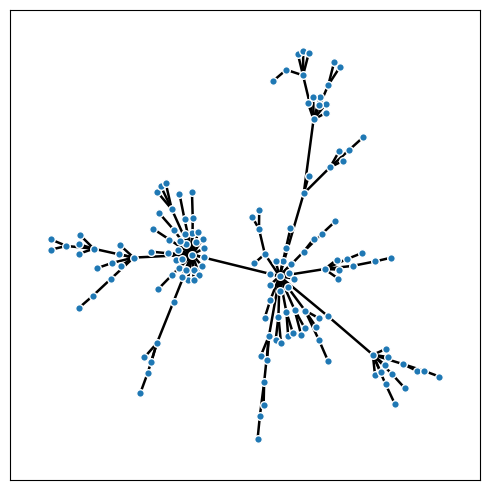

In [5]:
# Road
Ag=nx.barabasi_albert_graph(150,1)
f,ax=plt.subplots(1,1,figsize=(5,5))
layout = nx.spring_layout(Ag, iterations=100)
nodes = nx.draw_networkx_nodes(Ag,pos=layout,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,pos=layout, width = 1.8)
#ax[0].collections[1].set_alpha(1)
#ax[0].collections[0].set_linewidth(0.6)
#ax[0].collections[0].set_edgecolor("#FFFFFF")
plt.tight_layout()
#f.savefig("Euro-road-net.pdf")

In [6]:
# Laplacian
L0=nx.laplacian_matrix(Ag, nodelist = Ag.nodes()).todense()
e,ev=np.linalg.eigh(L0)

# setting parameters for Entropic curves
exm = -1 # C curve starts from 10**taumin
exM = 4 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)


c:\Users\Utente\Desktop\Harmonic_Morph_2\Laplacian\In Equilibrium Laplacian\../..\HOLR_functions.py:305: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))
c:\Users\Utente\anaconda3\envs\Nuovo2_net\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [7]:
# Renorm
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, l = H_CF_curves_eq(Ag, t_e, se, 50, L0, stability = False)

C:\Users\Utente\AppData\Local\Temp\ipykernel_33804\447556646.py:99: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa * fraction) * N)


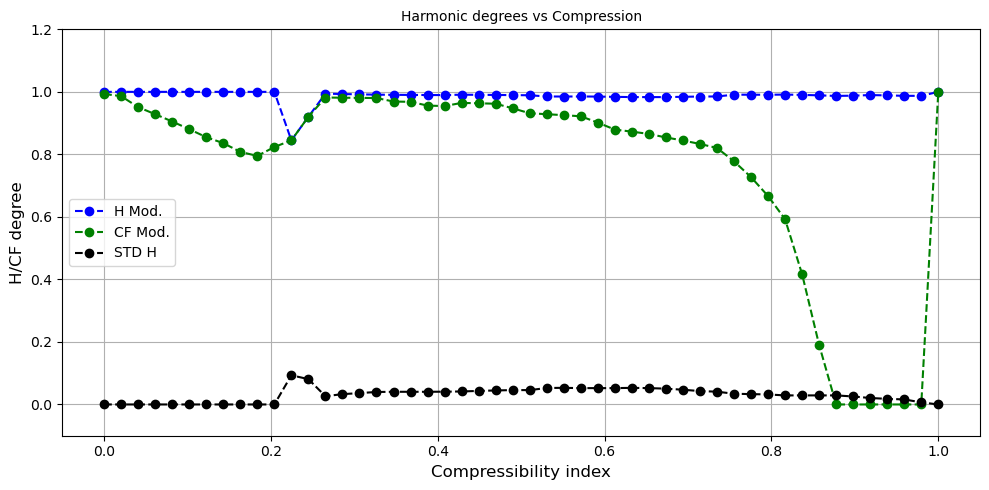

In [8]:
f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index")
plt.ylabel("H/CF degree")
plt.title("Harmonic degrees vs Compression")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()

C:\Users\Utente\AppData\Local\Temp\ipykernel_33804\447556646.py:57: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa* fraction) * N)


       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.986667 0.993333 0.004666 0.273333 0.546667 0.726505
0.5


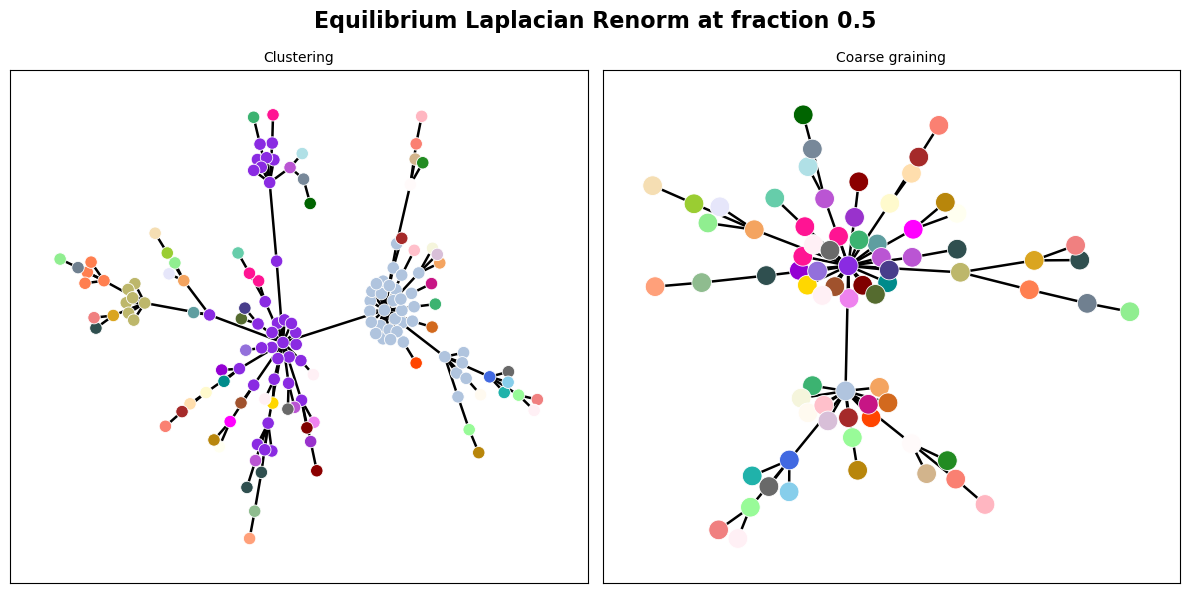

In [9]:
# Visualization
fraction = 0.5
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic_eq(Ag, t_e, se, fraction, L0, kappa=1)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot_eq(Ag, t_e, se, fraction, L0, kappa=4)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 80)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Equilibrium Laplacian Renorm at fraction {fraction}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig(f"NetCol_Lap_{t}.pdf")
print( len(G.nodes())/len(Ag.nodes()))

# MetSci Collab

379


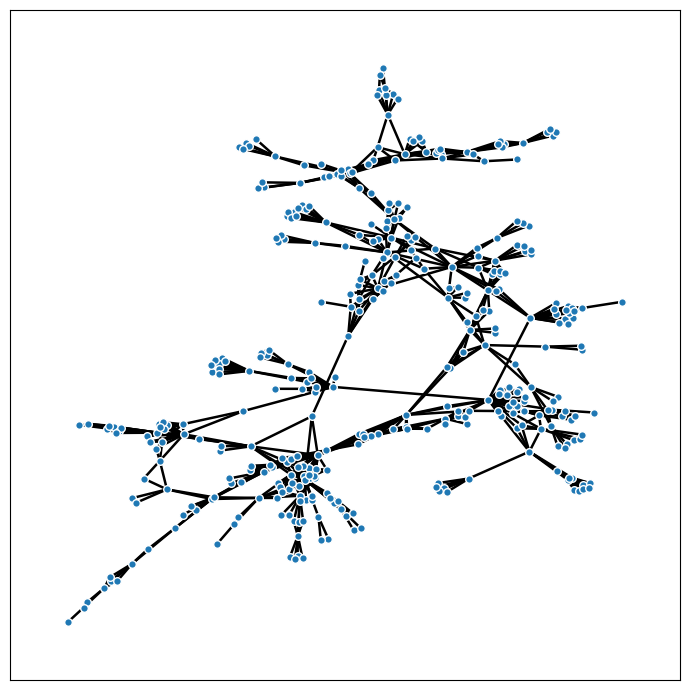

In [105]:
# Collab
Ag=data_1["NetSci Collab"]
f,ax=plt.subplots(1,1,figsize=(7,7))
layout = nx.spring_layout(Ag, iterations=100)
nodes = nx.draw_networkx_nodes(Ag,pos=layout,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,pos=layout, width = 1.8)
plt.tight_layout()
print(len(Ag.nodes()))

In [106]:
# Laplacian
L0=nx.laplacian_matrix(Ag, nodelist = Ag.nodes()).todense()
e,ev=np.linalg.eigh(L0)
# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 3 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)


C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\2257514.py:174: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))
C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [109]:
# Renorm
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, l = H_CF_curves_eq(Ag, t_e, se, 50, L0, stability = False)

C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\447556646.py:99: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa * fraction) * N)


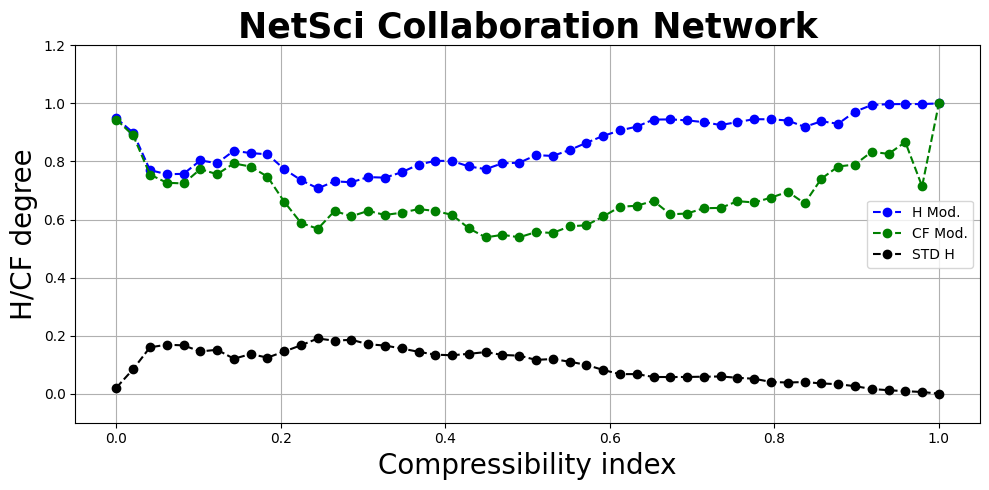

In [112]:
f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index", fontsize = 20)
plt.ylabel("H/CF degree", fontsize = 20)
plt.title("NetSci Collaboration Network",fontsize=25, fontweight="bold")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()
f.savefig("NetSci_Lap_Compr.pdf")

C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\447556646.py:57: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa* fraction) * N)


       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.891821 0.938622 0.057119 0.026385  0.27027  1.92755
0.09762532981530343


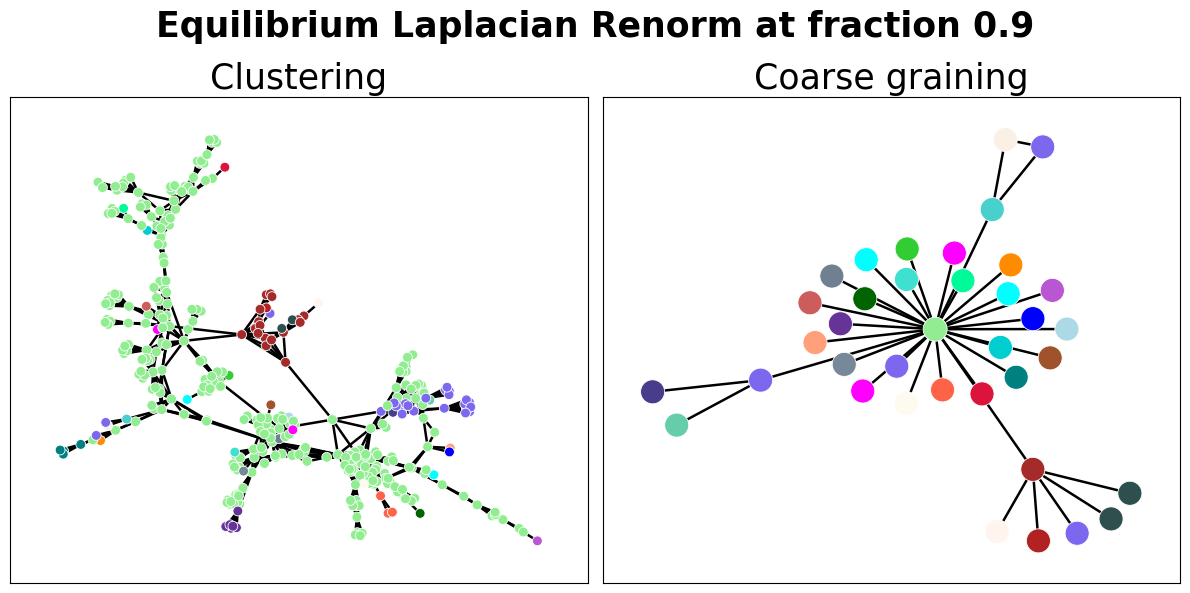

In [115]:
# Visualization
fraction = 0.9
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic_eq(Ag, t_e, se, fraction, L0, kappa=1)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot_eq(Ag, t_e, se, fraction, L0, kappa=4)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering", fontsize=25)

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining", fontsize=25)
f.suptitle(f"Equilibrium Laplacian Renorm at fraction {fraction}", fontsize=25, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig(f"NetCol_Lap_{t}.pdf")
print( len(G.nodes())/len(Ag.nodes()))
f.savefig("NetSci_eq.pdf")

# C. Elegans

453


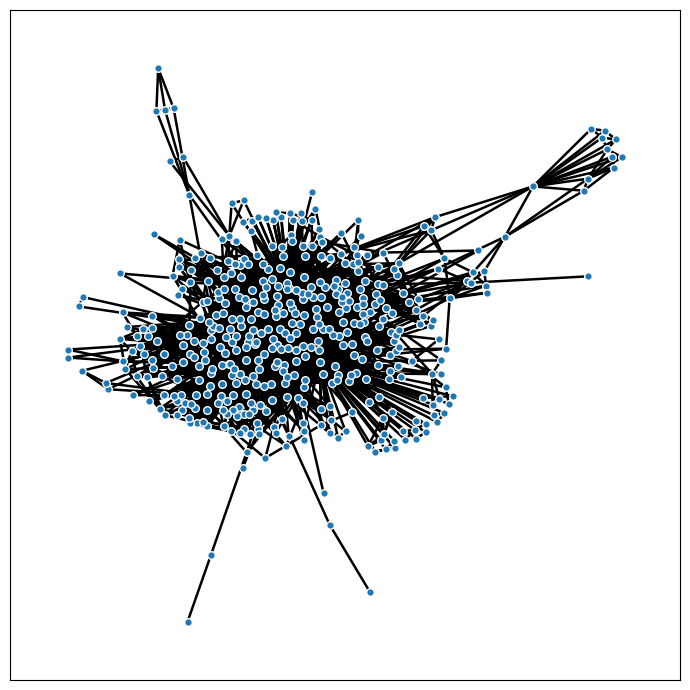

In [116]:
# C.Elegans
Ag=data_1["C. Elegans"]
f,ax=plt.subplots(1,1,figsize=(7,7))
layout = nx.spring_layout(Ag, iterations=100)
nodes = nx.draw_networkx_nodes(Ag,pos=layout,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,pos=layout, width = 1.8)
plt.tight_layout()
print(len(Ag.nodes()))

In [117]:
# Laplacian
L0=nx.laplacian_matrix(Ag).todense()
e,ev=np.linalg.eigh(L0)

# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 2 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)

# Harmonic Curves
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, t_h = H_CF_curves(Ag,L0,100)

C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\2257514.py:174: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))


In [120]:
# Renorm
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, l = H_CF_curves_eq(Ag, t_e, se, 50, L0, stability = False)

C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\447556646.py:99: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa * fraction) * N)


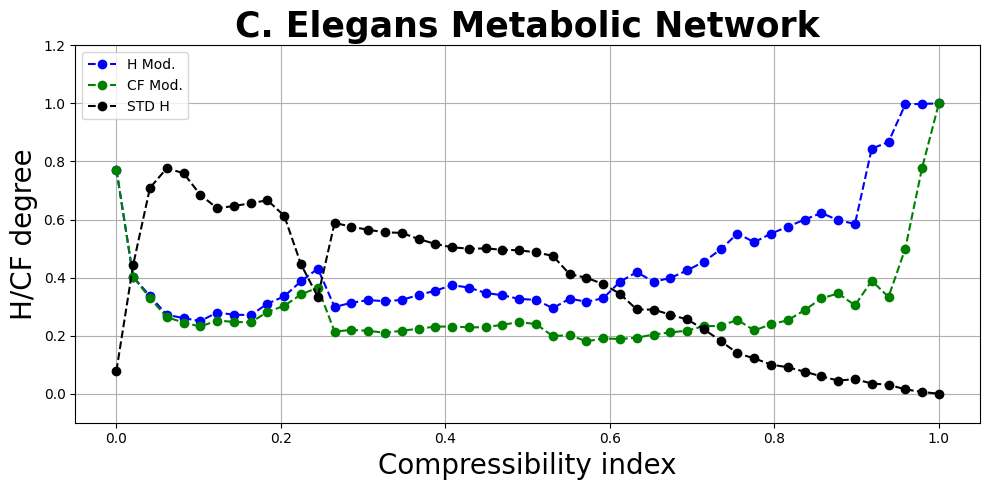

In [121]:
f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index", fontsize = 20)
plt.ylabel("H/CF degree", fontsize = 20)
plt.title("C. Elegans Metabolic Network",fontsize=25, fontweight="bold")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()
f.savefig("Celegans_eq_Lap_Compr.pdf")

C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\447556646.py:57: RuntimeWarning: divide by zero encountered in log
  target_value = np.log((1 - kappa* fraction) * N)


       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.216336 0.224856 0.759587 0.134658 0.179941 0.932774
0.7483443708609272


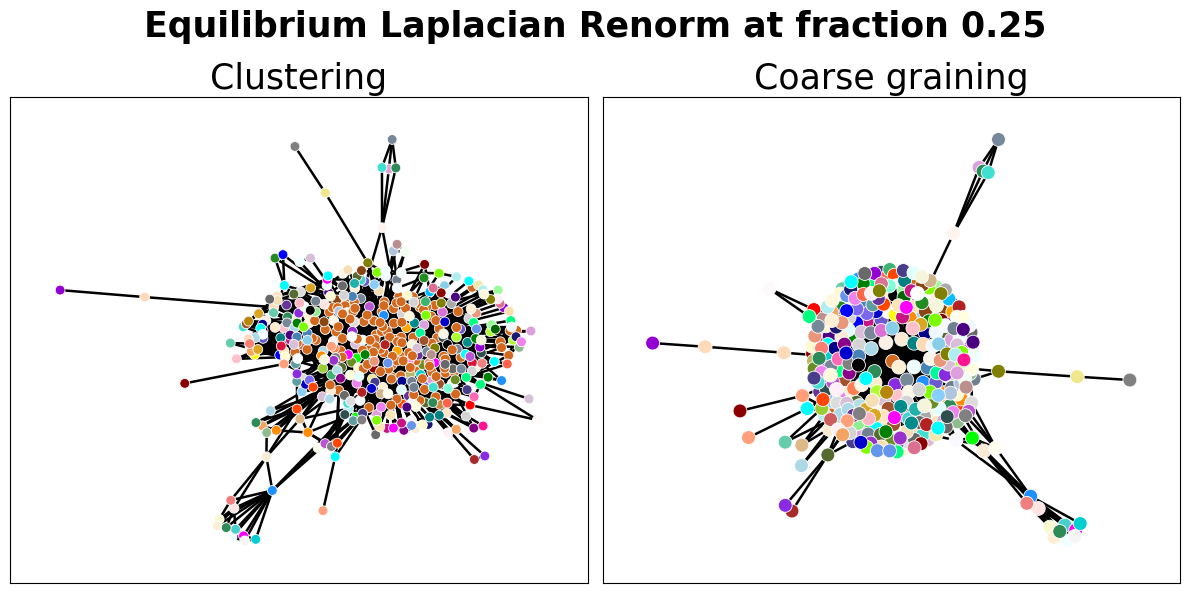

In [128]:
# Visualization
fraction = 0.25
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic_eq(Ag, t_e, se, fraction, L0, kappa=1)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot_eq(Ag, t_e, se, fraction, L0, kappa=4)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering", fontsize=25)

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 100)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining", fontsize=25)
f.suptitle(f"Equilibrium Laplacian Renorm at fraction {fraction}", fontsize=25, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig(f"NetCol_Lap_{t}.pdf")
print( len(G.nodes())/len(Ag.nodes()))
f.savefig("Ce_eq.pdf")

# Animal net: Tortoise

In [10]:
Ag=data_4["Animal net: Tortoise"]
print(len(Ag.nodes()))

496


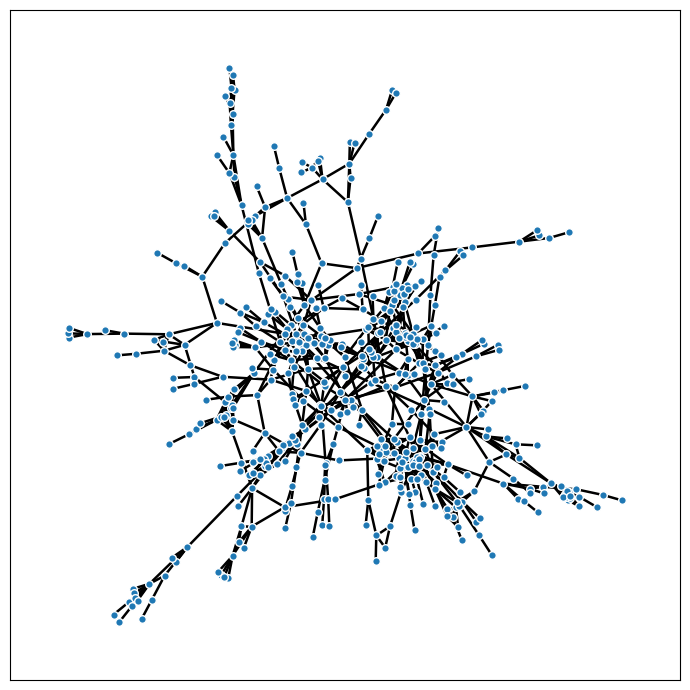

In [4]:
f,ax=plt.subplots(1,1,figsize=(7,7))
layout = nx.spring_layout(Ag, iterations=100)
nodes = nx.draw_networkx_nodes(Ag,pos=layout,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,pos=layout, width = 1.8)
plt.tight_layout()

In [5]:
# Laplacian
L0=nx.laplacian_matrix(Ag).todense()
e,ev=np.linalg.eigh(L0)

# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 4 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)


C:\Users\Utente\AppData\Local\Temp\ipykernel_16356\2257514.py:174: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))
C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [134]:
# Renorm
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, l = H_CF_curves_eq(Ag, t_e, se, 50, L0)

C:\Users\Utente\AppData\Local\Temp\ipykernel_28072\447556646.py:99: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa * fraction) * N)


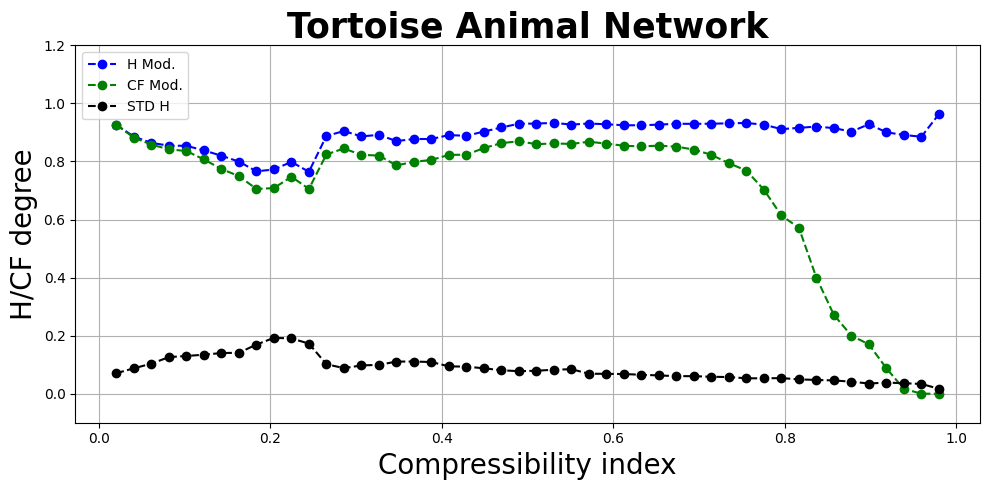

In [135]:
f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index", fontsize = 20)
plt.ylabel("H/CF degree", fontsize = 20)
plt.title("Tortoise Animal Network",fontsize=25, fontweight="bold")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()
f.savefig("Tort_eq_Lap_Compr.pdf")

C:\Users\Utente\AppData\Local\Temp\ipykernel_16356\447556646.py:57: RuntimeWarning: invalid value encountered in log
  target_value = np.log((1 - kappa* fraction) * N)


       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.693548 0.794998 0.136151 0.104839 0.344595 1.256939
0.29838709677419356


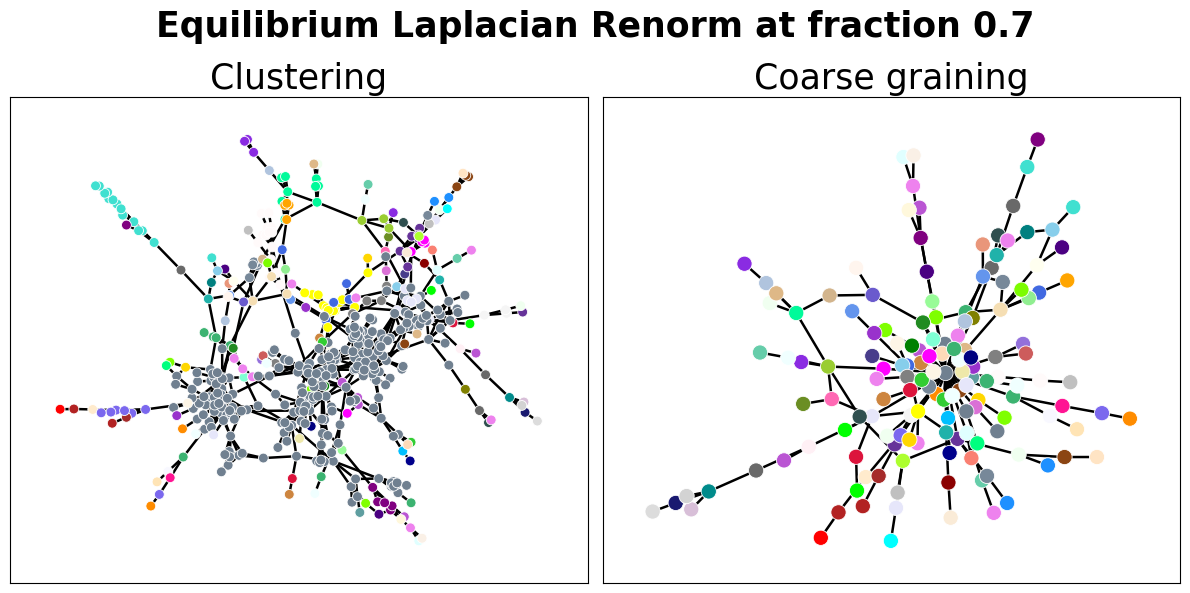

In [15]:
# Visualization
fraction = 0.7
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic_eq(Ag, t_e, se, fraction, L0, kappa=1)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot_eq(Ag, t_e, se, fraction, L0, kappa=4)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering", fontsize=25)

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 120)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining", fontsize=25)
f.suptitle(f"Equilibrium Laplacian Renorm at fraction {fraction}", fontsize=25, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig(f"NetCol_Lap_{t}.pdf")
print( len(G.nodes())/len(Ag.nodes()))
f.savefig("Tort_eq.pdf")